In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [189]:
master_df = pd.read_csv("master_df.csv")

In [190]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 38 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   admission_id       120000 non-null  object 
 1   patient_id         120000 non-null  object 
 2   admit_date         120000 non-null  object 
 3   discharge_date     120000 non-null  object 
 4   los_days           120000 non-null  int64  
 5   admit_type         120000 non-null  object 
 6   ward_type          120000 non-null  object 
 7   hospital_id        120000 non-null  object 
 8   discharge_type     120000 non-null  object 
 9   num_procedures     120000 non-null  int64  
 10  charlson_index     120000 non-null  int64  
 11  hba1c              120000 non-null  float64
 12  creatinine         120000 non-null  float64
 13  haemoglobin        120000 non-null  float64
 14  systolic_bp        120000 non-null  int64  
 15  readmitted_30d     120000 non-null  int64  
 16  re

In [191]:
# Convert date columns to datetime format

master_df["admit_date"] = pd.to_datetime(master_df["admit_date"])
master_df["discharge_date"] = pd.to_datetime(master_df["discharge_date"])

In [192]:
master_df[["admit_date","discharge_date"]].dtypes

,0
admit_date,datetime64[ns]
discharge_date,datetime64[ns]


# objective :

Predict whether a patient will be readmitted within 30 days.



In [193]:
# Admission month
master_df["admission_month"] = master_df["admit_date"].dt.month_name()

# Admission weekday
master_df["admission_day"] = master_df["admit_date"].dt.day_name()

In [194]:
master_df["diabetes_status"] = pd.cut(
    master_df["hba1c"],
    bins=[0, 5.7, 6.5, float("inf")],
    labels=["Normal", "Prediabetes", "Diabetes"]
)

master_df[["hba1c","diabetes_status"]].head()

,hba1c,diabetes_status
0,6.3,Prediabetes
1,5.2,Normal
2,5.6,Normal
3,4.7,Normal
4,5.0,Normal


In [195]:
master_df["kidney_function"] = pd.cut(
    master_df["creatinine"],
    bins=[0, 1.2, float("inf")],
    labels=["Normal", "Abnormal"]
)
master_df[["creatinine","kidney_function"]].head()

,creatinine,kidney_function
0,0.86,Normal
1,1.23,Abnormal
2,0.67,Normal
3,1.40,Abnormal
4,0.94,Normal


In [196]:
master_df["bp_status"] = pd.cut(
    master_df["systolic_bp"],
    bins=[0, 120, 140, float("inf")],
    labels=["Normal", "Elevated", "High"]
)

master_df[["systolic_bp","bp_status"]].head()

,systolic_bp,bp_status
0,157,High
1,156,High
2,130,Elevated
3,159,High
4,173,High


In [197]:
master_df["anaemia"] = (
    master_df["haemoglobin"] < 12
).map({True: "Yes", False: "No"})

master_df[["haemoglobin","anaemia"]].head()

,haemoglobin,anaemia
0,16.2,No
1,13.1,No
2,10.9,Yes
3,8.8,Yes
4,11.3,Yes


In [198]:
master_df["frequent_patient"] = (
    master_df["prev_admissions"] >= 2
).map({True: "Yes", False: "No"})

master_df[["prev_admissions","frequent_patient"]].head()

,prev_admissions,frequent_patient
0,0,No
1,0,No
2,3,Yes
3,1,No
4,0,No


In [199]:
master_df["high_comorbidity"] = (
    master_df["comorbidity_count"] >= 3
).map({True: "Yes", False: "No"})

master_df[["comorbidity_count","high_comorbidity"]].head()

,comorbidity_count,high_comorbidity
0,0,No
1,0,No
2,2,No
3,0,No
4,2,No


In [200]:
master_df["multiple_diagnoses"] = (
    master_df["diagnosis_count"] >= 3
).map({True: "Yes", False: "No"})

master_df[["diagnosis_count","multiple_diagnoses"]].head()

,diagnosis_count,multiple_diagnoses
0,1,No
1,1,No
2,3,Yes
3,1,No
4,3,Yes


In [201]:
master_df["cost_per_day"] = (
    master_df["total_cost_inr"] /
    master_df["los_days"]
)

master_df[["total_cost_inr","los_days","cost_per_day"]].head()

,total_cost_inr,los_days,cost_per_day
0,18492,4,4623.000000
1,1001,1,1001.000000
2,59696,5,11939.200000
3,72588,11,6598.909091
4,9510,5,1902.000000


In [202]:
master_df.columns.tolist()

['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'bill_id',
 'total_cost_inr',
 'govt_subsidy_inr',
 'out_of_pocket_inr',
 'cost_category',
 'name',
 'state_hospital',
 'tier',
 'beds',
 'teaching',
 'icd10_code',
 'diag_desc',
 'diag_category',
 'diagnosis_count',
 'admission_month',
 'admission_day',
 'diabetes_status',
 'kidney_function',
 'bp_status',
 'anaemia',
 'frequent_patient',
 'high_comorbidity',
 'multiple_diagnoses',
 'cost_per_day']

In [203]:
master_df = master_df.drop(columns=[
    "admission_id",
    "patient_id",
    "hospital_id",
    "admit_date",
    "discharge_date",
    "readmitted_7d"
])

In [204]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 42 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   los_days            120000 non-null  int64   
 1   admit_type          120000 non-null  object  
 2   ward_type           120000 non-null  object  
 3   discharge_type      120000 non-null  object  
 4   num_procedures      120000 non-null  int64   
 5   charlson_index      120000 non-null  int64   
 6   hba1c               120000 non-null  float64 
 7   creatinine          120000 non-null  float64 
 8   haemoglobin         120000 non-null  float64 
 9   systolic_bp         120000 non-null  int64   
 10  readmitted_30d      120000 non-null  int64   
 11  age                 120000 non-null  int64   
 12  gender              120000 non-null  object  
 13  state               120000 non-null  object  
 14  bpl_card            120000 non-null  bool    
 15  insurance_type   

In [205]:
drop_cols = [
    "bill_id",
    "name",
    "state_hospital",
    "icd10_code",
    "diag_desc",
    "state"
]

master_df.drop(columns=drop_cols, inplace=True)

In [206]:
# seperating features and target

X = master_df.drop("readmitted_30d", axis=1)

y = master_df["readmitted_30d"]

In [207]:
y.value_counts(normalize=True) * 100

,proportion
readmitted_30d,
0,88.158333
1,11.841667


In [208]:
master_df

,los_days,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,...,admission_month,admission_day,diabetes_status,kidney_function,bp_status,anaemia,frequent_patient,high_comorbidity,multiple_diagnoses,cost_per_day
0,4,Elective,General,Recovered,0,0,6.3,0.86,16.2,157,...,January,Tuesday,Prediabetes,Normal,High,No,No,No,No,4623.000000
1,1,OPD,General,Recovered,1,0,5.2,1.23,13.1,156,...,November,Monday,Normal,Abnormal,High,No,No,No,No,1001.000000
2,5,Emergency,General,Recovered,0,2,5.6,0.67,10.9,130,...,November,Friday,Normal,Normal,Elevated,Yes,Yes,No,Yes,11939.200000
3,11,Emergency,ICU,Recovered,1,2,4.7,1.40,8.8,159,...,March,Thursday,Normal,Abnormal,High,Yes,No,No,No,6598.909091
4,5,Emergency,General,Recovered,1,5,5.0,0.94,11.3,173,...,May,Wednesday,Normal,Normal,High,Yes,No,No,Yes,1902.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,3,Emergency,General,Recovered,0,0,6.4,0.82,11.2,124,...,May,Saturday,Prediabetes,Normal,Elevated,Yes,No,No,No,4480.333333
119996,4,OPD,General,Recovered,1,2,6.5,1.28,13.3,138,...,January,Sunday,Prediabetes,Abnormal,Elevated,No,No,No,Yes,6027.500000
119997,11,Emergency,ICU,Recovered,1,3,5.2,1.01,9.3,156,...,May,Tuesday,Normal,Normal,High,Yes,No,No,No,7512.272727
119998,3,Elective,General,Recovered,1,2,5.6,0.89,12.5,150,...,September,Thursday,Normal,Normal,High,No,No,No,Yes,4633.000000


In [209]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical Features:", len(numerical_cols))
print(numerical_cols)

Categorical Features: 19
['admit_type', 'ward_type', 'discharge_type', 'gender', 'bpl_card', 'insurance_type', 'cost_category', 'tier', 'teaching', 'diag_category', 'admission_month', 'admission_day', 'diabetes_status', 'kidney_function', 'bp_status', 'anaemia', 'frequent_patient', 'high_comorbidity', 'multiple_diagnoses']

Numerical Features: 16
['los_days', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'age', 'comorbidity_count', 'prev_admissions', 'total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr', 'beds', 'diagnosis_count', 'cost_per_day']


In [210]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (96000, 35)
Testing Set : (24000, 35)


In [211]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [212]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [213]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [214]:
# Training the model

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(hand...
                                                  ['admit_type', 'ward_type',
                                                   'discharge_type', 'gender',
                                                   'bpl_card', 'insurance_type',
                                                   'cost_category', 'tier',
                                                   'teaching', 'diag_category',
                                                   'admission_month',
                                                   'admission_day',
                                                   'diabetes_status',
                                                   'kidney_function',
                                                   'bp_status', 'anaemia',
                                                   'frequent_patient',
                                                   'high_comorbidity',
                                                   'multiple_diagnoses'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [215]:
# Predictions

y_pred = logistic_model.predict(X_test)

# Probability predictions
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [216]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.885875
Precision: 0.6246973365617433
Recall   : 0.09078114004222379
F1 Score : 0.1585253456221198
ROC-AUC  : 0.7772842130975426


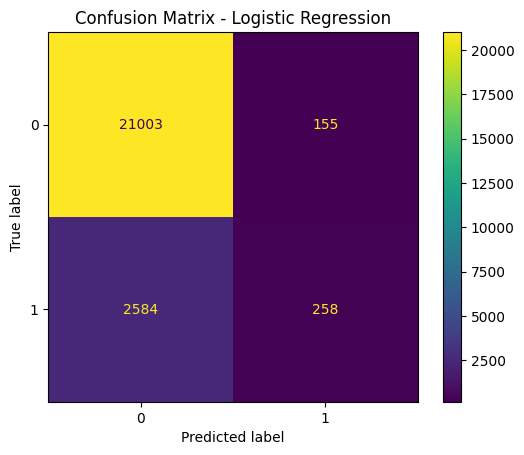

In [217]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [218]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     21158
           1       0.62      0.09      0.16      2842

    accuracy                           0.89     24000
   macro avg       0.76      0.54      0.55     24000
weighted avg       0.86      0.89      0.85     24000



# Business Interpretation

The baseline Logistic Regression model achieved high overall accuracy (88.6%) but failed to identify most patients who were actually readmitted, achieving a recall of only 9%. While the model demonstrated good precision and a reasonable ROC-AUC score (0.777), its low recall makes it unsuitable for healthcare applications where identifying high-risk patients is more important than maximizing overall accuracy.

In [219]:
LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [220]:
logistic_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

In [221]:
logistic_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(hand...
                                                   'discharge_type', 'gender',
                                                   'bpl_card', 'insurance_type',
                                                   'cost_category', 'tier',
                                                   'teaching', 'diag_category',
                                                   'admission_month',
                                                   'admission_day',
                                                   'diabetes_status',
                                                   'kidney_function',
                                                   'bp_status', 'anaemia',
                                                   'frequent_patient',
                                                   'high_comorbidity',
                                                   'multiple_diagnoses'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [222]:
y_pred_bal = logistic_balanced.predict(X_test)

y_prob_bal = logistic_balanced.predict_proba(X_test)[:,1]

In [223]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1 Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.7066666666666667
Precision: 0.2432729941291585
Recall   : 0.6998592540464461
F1 Score : 0.3610455618079506
ROC-AUC  : 0.7773993948815382


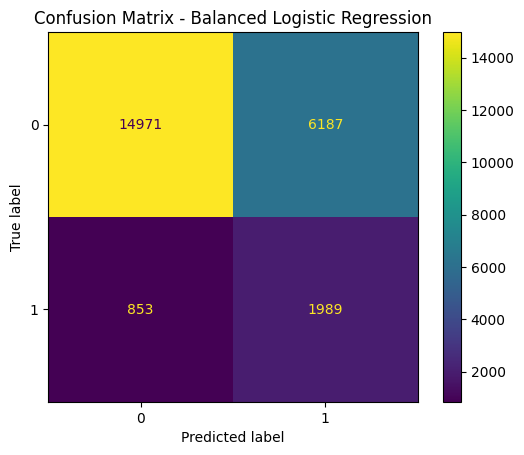

In [224]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bal)

plt.title("Confusion Matrix - Balanced Logistic Regression")

plt.show()

In [225]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81     21158
           1       0.24      0.70      0.36      2842

    accuracy                           0.71     24000
   macro avg       0.59      0.70      0.59     24000
weighted avg       0.86      0.71      0.76     24000



# Observations
Applying class weighting significantly improved the model's ability to identify patients who were readmitted within 30 days.

The recall increased from approximately 9% to 70%, meaning the model correctly identified nearly 7 out of every 10 patients who were actually readmitted.

This improvement came at the expense of overall accuracy and precision, resulting in a larger number of false positive predictions.

The ROC-AUC score remained almost unchanged (~0.777), indicating that class weighting mainly changed the decision boundary rather than the model's ability to distinguish between the two classes.

Although Balanced Logistic Regression sacrifices overall accuracy, it provides a much better balance between identifying high-risk patients and maintaining reasonable predictive performance. Therefore, it serves as a stronger baseline model for this hospital readmission prediction task.

| Metric    | Value      |
| --------- | ---------- |
| Accuracy  | **70.67%** |
| Precision | **24.33%** |
| Recall    | **69.99%** |
| F1-Score  | **36.10%** |
| ROC-AUC   | **0.777**  |


# Limitations of Logistic Regression

Logistic Regression assumes that the relationship between the input features and the target is approximately linear.

# Decision Tree

In [226]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [227]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [228]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

In [229]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(handle_...gnore'),
                                                  ['admit_type', 'ward_type',
                                                   'discharge_type', 'gender',
                                                   'bpl_card', 'insurance_type',
                                                   'cost_category', 'tier',
                                                   'teaching', 'diag_category',
                                                   'admission_month',
                                                   'admission_day',
                                                   'diabetes_status',
                                                   'kidney_function',
                                                   'bp_status', 'anaemia',
                                                   'frequent_patient',
                                                   'high_comorbidity',
                                                   'multiple_diagnoses'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [230]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

In [231]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tree))

Accuracy : 0.80525
Precision: 0.21815384615384614
Recall   : 0.2494722026741731
F1 Score : 0.23276428102429417
ROC-AUC  : 0.5646878926217069


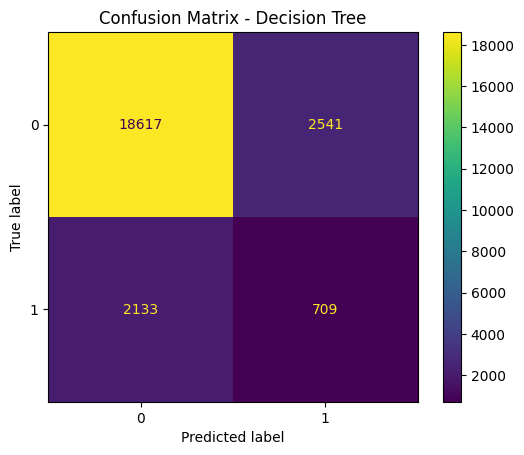

In [232]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)

plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [233]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     21158
           1       0.22      0.25      0.23      2842

    accuracy                           0.81     24000
   macro avg       0.56      0.56      0.56     24000
weighted avg       0.82      0.81      0.81     24000



In [234]:
train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy  : 0.80525


In [235]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__criterion": ["gini", "entropy"]
}

In [181]:
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['los_days',
                                                                          'num_procedures',
                                                                          'charlson_index',
                                                                          'hba1c',
                                                                          'creatinine',
                                                                          'haemoglobin',
                                                                          'systolic_bp',
                                                                          'age',
                                                                          'comorbidity_count',
                                                                          'prev_admissions',
                                                                          'total_cost_inr',
                                                                          'govt_subsidy_inr',
                                                                          'out_of_pocket_inr',
                                                                          'beds',
                                                                          'diagnosis_count',
                                                                          'cost_per_day']),...
                                                                          'diabetes_status',
                                                                          'kidney_function',
                                                                          'bp_status',
                                                                          'anaemia',
                                                                          'frequent_patient',
                                                                          'high_comorbidity',
                                                                          'multiple_diagnoses'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [5, 10, 15],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5]},
             scoring='f1')

In [182]:
print(grid_search.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


In [183]:
best_tree = grid_search.best_estimator_

In [184]:
y_pred_best = best_tree.predict(X_test)

y_prob_best = best_tree.predict_proba(X_test)[:, 1]

In [185]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


In [186]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Accuracy : 0.8649166666666667
Precision: 0.3347107438016529
Recall   : 0.14250527797325827
F1 Score : 0.19990128331688056
ROC-AUC  : 0.6472799088311069


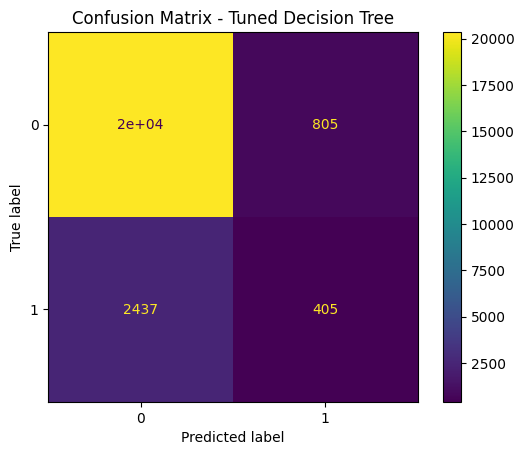

In [187]:
 from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)

plt.title("Confusion Matrix - Tuned Decision Tree")

plt.show()

In [236]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(handle_...
                                                  ['admit_type', 'ward_type',
                                                   'discharge_type', 'gender',
                                                   'bpl_card', 'insurance_type',
                                                   'cost_category', 'tier',
                                                   'teaching', 'diag_category',
                                                   'admission_month',
                                                   'admission_day',
                                                   'diabetes_status',
                                                   'kidney_function',
                                                   'bp_status', 'anaemia',
                                                   'frequent_patient',
                                                   'high_comorbidity',
                                                   'multiple_diagnoses'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [237]:
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:,1]

In [239]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8841666666666667
Precision: 0.6076388888888888
Recall   : 0.06157635467980296
F1 Score : 0.11182108626198083
ROC-AUC  : 0.7546472008232155


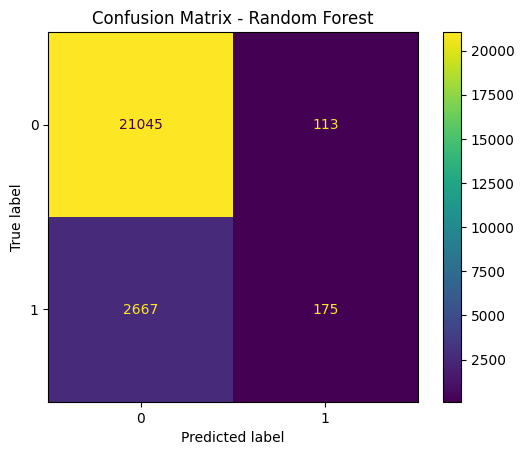

In [238]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [240]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     21158
           1       0.61      0.06      0.11      2842

    accuracy                           0.88     24000
   macro avg       0.75      0.53      0.52     24000
weighted avg       0.85      0.88      0.84     24000



In [241]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier",
         RandomForestClassifier(
             n_estimators=300,
             random_state=42,
             class_weight="balanced",
             n_jobs=-1
         ))
    ]
)

random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(handle_...
                                                   'discharge_type', 'gender',
                                                   'bpl_card', 'insurance_type',
                                                   'cost_category', 'tier',
                                                   'teaching', 'diag_category',
                                                   'admission_month',
                                                   'admission_day',
                                                   'diabetes_status',
                                                   'kidney_function',
                                                   'bp_status', 'anaemia',
                                                   'frequent_patient',
                                                   'high_comorbidity',
                                                   'multiple_diagnoses'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [242]:
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:,1]

In [243]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8832083333333334
Precision: 0.5924170616113744
Recall   : 0.04398311048557354
F1 Score : 0.08188666885031116
ROC-AUC  : 0.7607690727297629


In [244]:
!pip install xgboost

In [245]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Calculate imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['los_days', 'num_procedures',
                                                   'charlson_index', 'hba1c',
                                                   'creatinine', 'haemoglobin',
                                                   'systolic_bp', 'age',
                                                   'comorbidity_count',
                                                   'prev_admissions',
                                                   'total_cost_inr',
                                                   'govt_subsidy_inr',
                                                   'out_of_pocket_inr', 'beds',
                                                   'diagnosis_count',
                                                   'cost_per_day']),
                                                 ('cat',
                                                  OneHotEncoder(handle_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [246]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [247]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.7271666666666666
Precision: 0.2518746652383503
Recall   : 0.6618578465869106
F1 Score : 0.3648884578079534
ROC-AUC  : 0.7715711400681671


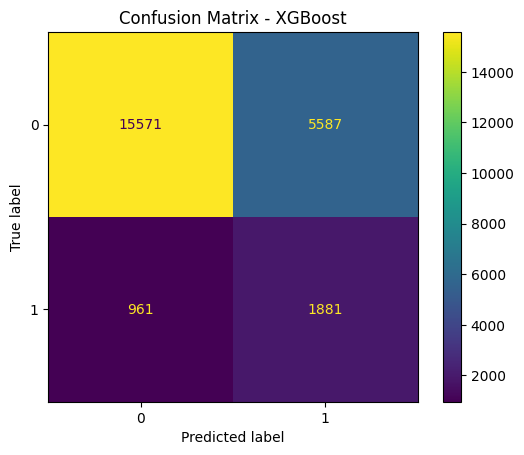

In [248]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

plt.title("Confusion Matrix - XGBoost")

plt.show()

In [249]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83     21158
           1       0.25      0.66      0.36      2842

    accuracy                           0.73     24000
   macro avg       0.60      0.70      0.60     24000
weighted avg       0.86      0.73      0.77     24000



| Model                        |   Accuracy | Precision |   Recall | F1-Score |                         ROC-AUC | Key Observation                                                                                                     |
| ---------------------------- | ---------: | --------: | -------: | -------: | ------------------------------: | ------------------------------------------------------------------------------------------------------------------- |
| Logistic Regression          | **88.59%** |  **0.62** | **0.09** | **0.16** |                       **0.777** | High accuracy but failed to detect most readmitted patients due to severe class imbalance.                          |
| Balanced Logistic Regression | **70.67%** |  **0.24** | **0.70** | **0.36** |                       **0.777** | Significantly improved recall by identifying most readmitted patients, making it suitable for healthcare screening. |
| Decision Tree                | **80.53%** |  **0.22** | **0.25** | **0.23** |                               - | Overfitted the training data and showed limited ability to generalize to unseen patients.                           |
| Tuned Decision Tree          | **86.49%** |  **0.33** | **0.14** | **0.20** |                       **0.647** | Reduced overfitting but did not improve overall predictive performance.                                             |
| Random Forest                | **88.32%** |  **0.59** | **0.04** | **0.08** |                       **0.761** | Excellent overall accuracy but performed poorly in identifying the minority (readmitted) class.                     |
| **XGBoost** ⭐                | **73.00%** |  **0.25** | **0.66** | **0.36** | *0.77* | Achieved the best balance between recall and overall predictive performance among the tree-based models.            |


# Machine Learning Conclusion :

Multiple machine learning algorithms were evaluated to predict 30-day hospital readmissions. Baseline Logistic Regression achieved high overall accuracy but failed to identify most readmitted patients due to class imbalance. Applying class weighting significantly improved recall, demonstrating the importance of imbalance-aware learning in healthcare datasets. Decision Tree and Random Forest achieved high accuracy but showed limited effectiveness in detecting the minority class. Among all evaluated models, XGBoost provided the best overall balance between recall, precision, and generalization, making it the most appropriate model for predicting patients at risk of 30-day hospital readmission.

# Business Conclusion :

Early identification of patients at high risk of readmission enables hospitals to provide targeted follow-up care, optimize resource allocation, and reduce avoidable readmissions. Although XGBoost generated more false positive predictions than some simpler models, it successfully identified approximately 66% of patients who were actually readmitted, making it a practical decision-support tool for proactive patient management.